In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("wine_data.csv",header=None,usecols=[0,1,2])

In [7]:
df.columns=["Class Label","Alcohal","Malic Acid"]

In [8]:
df # X' = X-median/IQR means Q3 75% - 25% median = 50% median =0 and IQR = 1

,Class Label,Alcohal,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Malic Acid', ylabel='Density'>

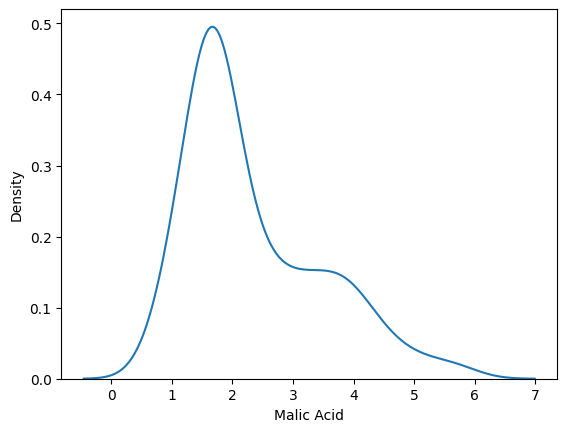

In [10]:
sns.kdeplot(df["Malic Acid"])

<Axes: xlabel='Alcohal', ylabel='Malic Acid'>

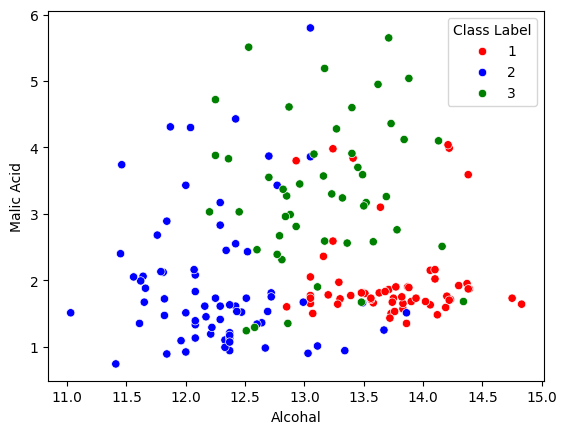

In [11]:
color_dict={1:"red",2:"blue",3:"green"}
sns.scatterplot(x=df["Alcohal"],y=df["Malic Acid"],hue=df["Class Label"],palette=color_dict)

In [13]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(df.drop("Class Label",axis=1),
                                                df["Class Label"],
                                                test_size=0.4,
                                                random_state=0
                                                )

In [17]:
X_train.shape

((106, 2),
 54     1
 151    3
 63     2
 55     1
 123    2
       ..
 62     2
 2      1
 59     2
 95     2
 96     2
 Name: Class Label, Length: 72, dtype: int64)

In [18]:
Y_train.shape

(106,)

In [19]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

scaler.fit(X_train)

X_train_Scaled = scaler.transform(X_train)
X_test_Scaled = scaler.transform(X_test)


In [20]:
X_train_Scaled

array([[ 0.14981273,  1.37152209],
       [ 0.79400749,  0.18003273],
       [-1.07116105, -0.3502455 ],
       [-0.03745318, -0.14075286],
       [-0.20224719,  0.33060556],
       [ 0.32958801, -0.14075286],
       [-1.1835206 ,  1.21440262],
       [-0.72659176,  0.18003273],
       [-0.91385768, -0.27168576],
       [ 0.3071161 ,  1.18821604],
       [-0.62921348,  0.74959083],
       [ 0.00749064, -0.101473  ],
       [ 0.09737828,  2.16366612],
       [-0.71910112, -0.36333879],
       [-0.65168539, -0.28477905],
       [-0.46441948,  1.66612111],
       [-0.87640449,  1.58756137],
       [-0.62172285, -0.45499182],
       [ 0.6741573 , -0.101473  ],
       [ 0.79400749,  0.08837971],
       [-0.27715356, -0.59247136],
       [ 1.28089888, -0.101473  ],
       [-0.5917603 ,  1.85597381],
       [-0.1423221 , -0.18657938],
       [ 0.51685393,  1.6202946 ],
       [ 0.76404494, -0.16693944],
       [ 0.44194757, -0.04909984],
       [-0.53183521, -0.58592471],
       [ 0.58426966,

In [21]:
X_train_Scaled = pd.DataFrame(X_train_Scaled,columns=X_train.columns)
X_test_Scaled = pd.DataFrame(X_test_Scaled,columns=X_test.columns)

In [23]:
X_train_Scaled
X_test_Scaled

,Alcohal,Malic Acid
0,0.524345,-0.140753
1,-0.187266,0.513912
2,-0.501873,-0.494272
3,0.389513,-0.101473
4,0.007491,2.563011
...,...,...
67,0.471910,-0.415712
68,0.089888,0.310966
69,-0.501873,-0.618658
70,-0.426966,-0.238953


In [24]:
np.round(X_train.describe(),1)

,Alcohal,Malic Acid
count,106.0,106.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.3,1.6
50%,13.0,1.9
75%,13.7,3.2
max,14.8,5.6


In [25]:
np.round(X_train_Scaled.describe(),1)

,Alcohal,Malic Acid
count,106.0,106.0
mean,-0.0,0.3
std,0.6,0.7
min,-1.5,-0.7
25%,-0.5,-0.2
50%,0.0,0.0
75%,0.5,0.8
max,1.3,2.5


Text(0.5, 1.0, 'After Scaling')

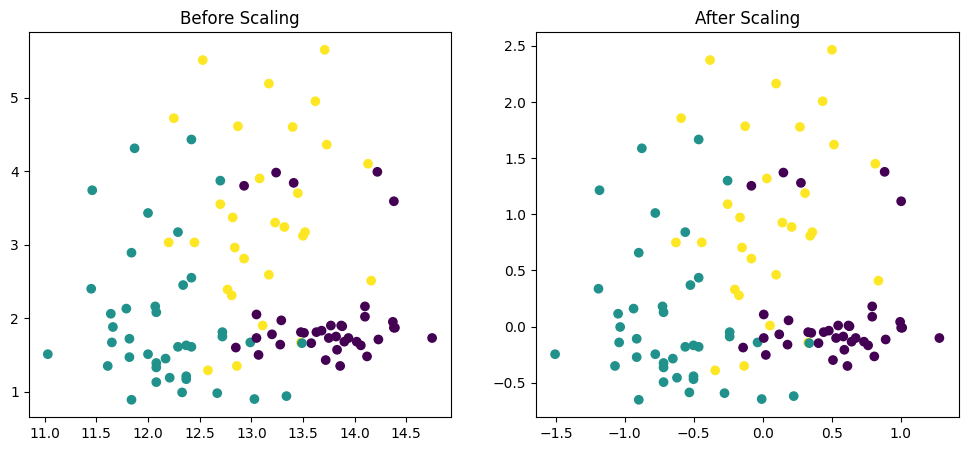

In [26]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(X_train["Alcohal"],X_train["Malic Acid"],c=Y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_Scaled["Alcohal"],X_train_Scaled["Malic Acid"],c=Y_train)
ax2.set_title("After Scaling")

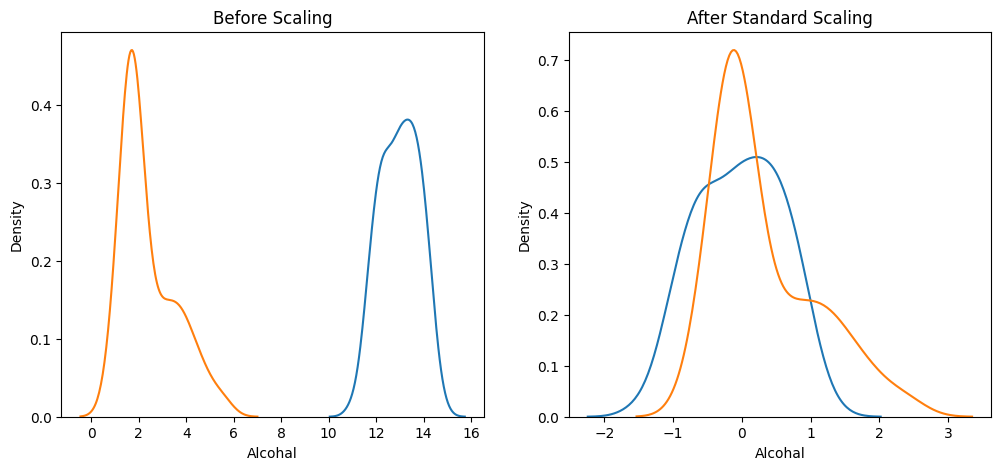

In [27]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohal'], ax=ax1)
sns.kdeplot(X_train['Malic Acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_Scaled['Alcohal'], ax=ax2)
sns.kdeplot(X_train_Scaled['Malic Acid'], ax=ax2)
plt.show()

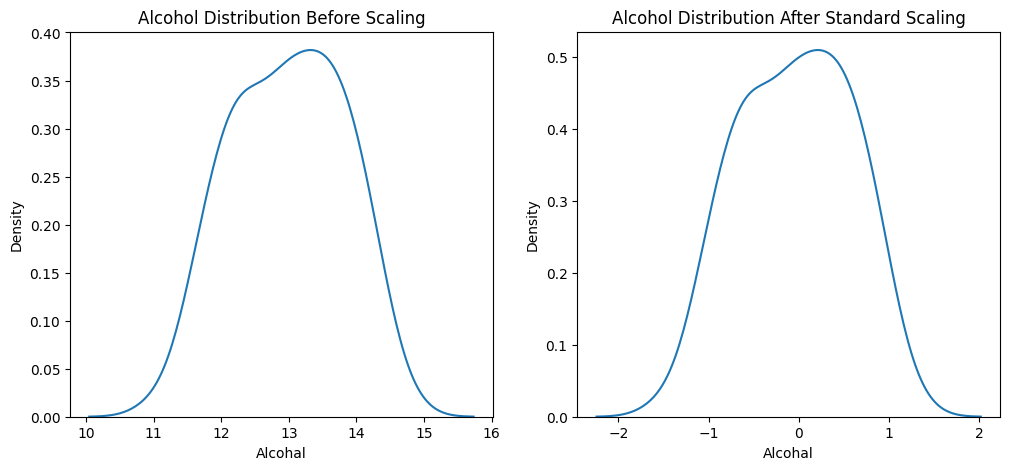

In [28]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohal'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_Scaled['Alcohal'], ax=ax2)
plt.show()

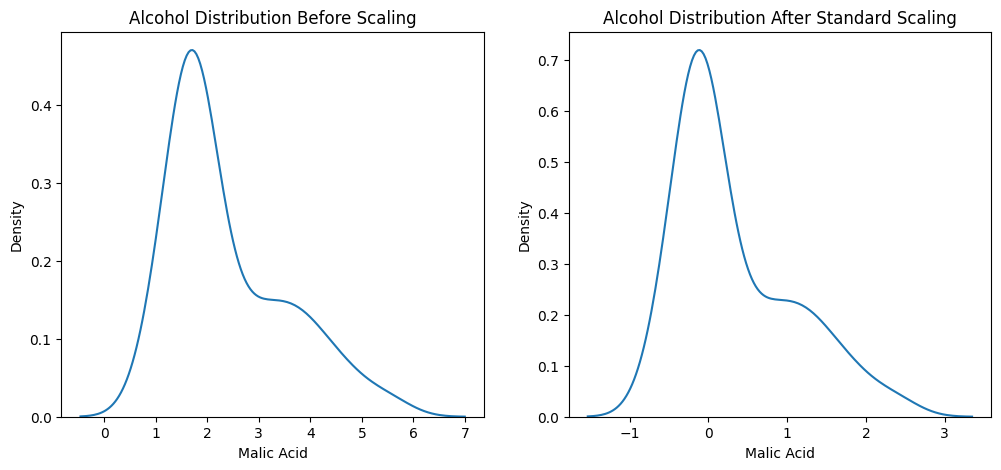

In [29]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Malic Acid'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_Scaled['Malic Acid'], ax=ax2)
plt.show()